# Spectral classification of SDSS sources with GalSpecNet

Trains `astrospec.models.galspecnet.GalSpecNet`
([Wu et al. 2023, MNRAS 527:1163](https://doi.org/10.1093/mnras/stad2913)) to
separate the three SDSS pipeline classes, GALAXY, QSO and STAR, from optical
spectra alone.

<img src="../assets/source%20classification.jpg" alt="spectra source classification" width="800">

*[Source Credit](https://hsweb.hs.uni-hamburg.de/projects/observational-astronomy/qsoal/)*

The data is the [MultimodalUniverse](https://huggingface.co/MultimodalUniverse)
SDSS release. `utils/sdss.py` reads a local HDF5 copy when `ASTROSPEC_SDSS_ROOT`
points at one and streams
[`MultimodalUniverse/sdss`](https://huggingface.co/datasets/MultimodalUniverse/sdss)
otherwise. Only the local copy carries the `CLASS` column this notebook trains
on, so this notebook needs `ASTROSPEC_SDSS_ROOT` set to a directory of
`healpix=*/` shards. Set it in a `.env` file in this directory (gitignored; see
`examples/README.md`) to avoid exporting it by hand. `utils/__init__.py`
loads it automatically.

Two things about the setup. The labels are the SDSS pipeline's own
template-fit classification, not independent ground truth, so the model learns
to imitate that pipeline. And GalSpecNet is a fixed-grid model. Its head is a
flat MLP over the final convolutional activations, so every spectrum has to
arrive on the same wavelength grid. SDSS spectra do not. They share a log-lambda
pixel spacing but cover slightly different windows, so `utils.sdss` interpolates
them onto one common grid first. AstroSpec ships no
resampling of its own; that choice belongs to the dataset.

## Install example-only dependencies

Not part of AstroSpec's core install, only needed for this example.

In [1]:
!pip install -q h5py datasets scikit-learn matplotlib tqdm python-dotenv

## Imports

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

import astrospec
from utils import sdss

torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load a natural-proportion sample

6,000 spectra in whatever mix of GALAXY / QSO / STAR the survey actually
produces. SDSS is dominated by GALAXY with QSO the rarest, and that skew is
real, not a sampling artifact, so we keep it and correct for it with class
weights in the loss instead of balancing the data.

In [3]:
flux, labels = sdss.load_sample(n=6000)
flux = sdss.standardize(flux)
flux.shape, np.bincount(labels), sdss.CLASS_NAMES

((6000, 3841), array([4476,  444, 1080]), ['GALAXY', 'QSO', 'STAR'])

## What the three classes look like

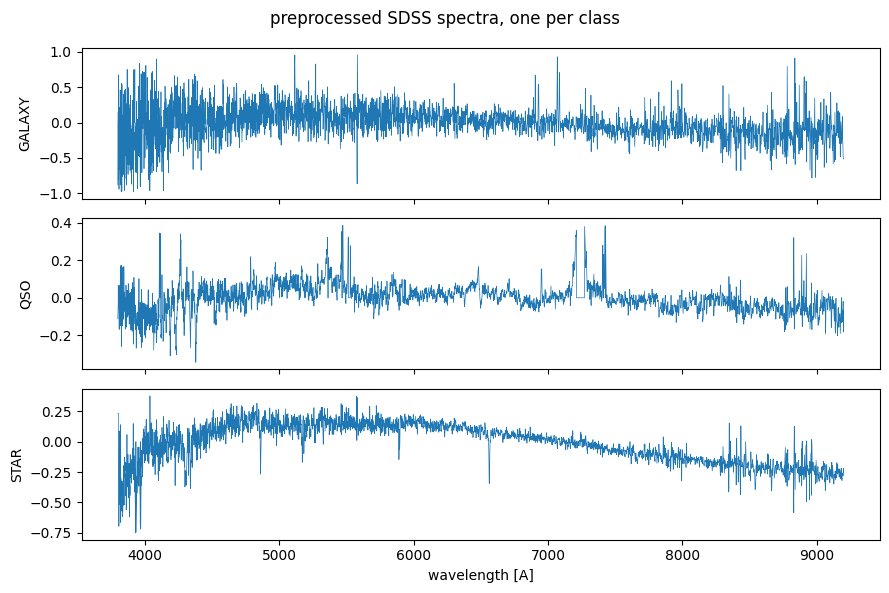

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for ax, name in zip(axes, sdss.CLASS_NAMES):
    i = int(np.flatnonzero(labels == sdss.CLASS_NAMES.index(name))[0])
    ax.plot(sdss.COMMON_GRID, flux[i], lw=0.5)
    ax.set_ylabel(name)
axes[-1].set_xlabel("wavelength [A]")
fig.suptitle("preprocessed SDSS spectra, one per class")
fig.tight_layout()

## Split 70/10/20

Stratified, so each split keeps the same (imbalanced) class proportions.

In [5]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(labels))
train_idx, test_idx = train_test_split(idx, test_size=0.2, stratify=labels, random_state=0)
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.125, stratify=labels[train_idx], random_state=0
)

def loader(indices, shuffle):
    dataset = TensorDataset(
        torch.from_numpy(flux[indices]), torch.from_numpy(labels[indices])
    )
    return DataLoader(dataset, batch_size=64, shuffle=shuffle)

train_loader, val_loader, test_loader = (
    loader(train_idx, True), loader(val_idx, False), loader(test_idx, False)
)
len(train_idx), len(val_idx), len(test_idx)

(4200, 600, 1200)

## The model

Constructed through the registry; `astrospec.models.galspecnet.GalSpecNet` is
importable directly and takes the same arguments. `input_length` is the grid the
spectra were resampled onto, and the model consumes `flux` only, not
`wavelength`, `ivar`, `mask`, or `lsf_sigma`.

In [6]:
model = astrospec.create_model(
    "galspecnet", input_length=flux.shape[1], num_classes=len(sdss.CLASS_NAMES)
).to(device)
sum(p.numel() for p in model.parameters())

506627

## Train

Class weights come from the training split's own label counts (inverse
frequency, mean-normalized), so the rare QSO class costs more per mistake
than GALAXY without changing what the model is trained or evaluated on.

In [7]:
EPOCHS = 10
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

class_counts = np.bincount(labels[train_idx], minlength=len(sdss.CLASS_NAMES))
class_weight = torch.tensor(1.0 / class_counts, dtype=torch.float32)
class_weight = (class_weight / class_weight.mean()).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weight)

def evaluate(data_loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in data_loader:
            pred = model(x.to(device)).argmax(-1).cpu()
            correct += (pred == y).sum().item()
            total += len(y)
    return correct / total

epoch_bar = tqdm(range(EPOCHS), desc="training")
for epoch in epoch_bar:
    model.train()
    running = 0.0
    for x, y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(x.to(device)), y.to(device))
        loss.backward()
        optimizer.step()
        running += loss.item() * len(y)
    epoch_bar.set_postfix(
        train_loss=f"{running / len(train_idx):.4f}",
        val_acc=f"{evaluate(val_loader):.4f}",
    )

training:   0%|          | 0/10 [00:00<?, ?it/s]

training:   0%|          | 0/10 [00:02<?, ?it/s, train_loss=1.0878, val_acc=0.6017]

training:  10%|█         | 1/10 [00:02<00:18,  2.00s/it, train_loss=1.0878, val_acc=0.6017]

training:  10%|█         | 1/10 [00:03<00:18,  2.00s/it, train_loss=0.8960, val_acc=0.7833]

training:  20%|██        | 2/10 [00:03<00:14,  1.80s/it, train_loss=0.8960, val_acc=0.7833]

...

training:  80%|████████  | 8/10 [00:15<00:03,  1.72s/it, train_loss=0.3482, val_acc=0.9333]

training:  90%|█████████ | 9/10 [00:15<00:01,  1.70s/it, train_loss=0.3482, val_acc=0.9333]

training:  90%|█████████ | 9/10 [00:17<00:01,  1.70s/it, train_loss=0.3314, val_acc=0.9417]

training: 100%|██████████| 10/10 [00:17<00:00,  1.70s/it, train_loss=0.3314, val_acc=0.9417]

training: 100%|██████████| 10/10 [00:17<00:00,  1.73s/it, train_loss=0.3314, val_acc=0.9417]

## Test accuracy and confusion matrix

              precision    recall  f1-score   support

      GALAXY      0.974     0.950     0.962       895
         QSO      0.589     0.854     0.697        89
        STAR      0.955     0.875     0.913       216

    accuracy                          0.929      1200
   macro avg      0.839     0.893     0.857      1200
weighted avg      0.942     0.929     0.933      1200



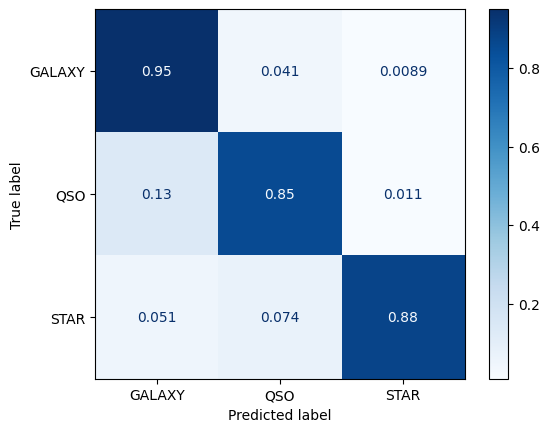

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

model.eval()
preds = []
with torch.no_grad():
    for x, _ in test_loader:
        preds.append(model(x.to(device)).argmax(-1).cpu())
preds = torch.cat(preds).numpy()

print(classification_report(labels[test_idx], preds, target_names=sdss.CLASS_NAMES, digits=3))
ConfusionMatrixDisplay.from_predictions(
    labels[test_idx], preds, display_labels=sdss.CLASS_NAMES, normalize="true", cmap="Blues"
)

## Notes

The paper trains on a larger SDSS DR16 sample and reports accuracies in the
high nineties; this is a tutorial-scale run on 6,000 spectra from one
sub-survey, so treat the numbers above as a sanity check on the wiring, not a
reproduction. Overall accuracy is also a weaker signal here than usual, since
GALAXY dominates the sample; the per-class precision/recall in the
classification report above is the number that matters.

The residual errors concentrate on QSOs, which have the lowest per-class
precision and recall of the three even with class weighting. That is the
expected failure mode here. A fixed-grid CNN sees a spectrum at whatever
redshift it was observed, so the emission lines that identify a quasar sit at
a different pixel for every object, while a star's continuum shape and
absorption features stay put. The library carries models that take
`wavelength` as an input, or that pretrain a representation of the sequence
before you attach a classifier, for exactly this reason.